<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
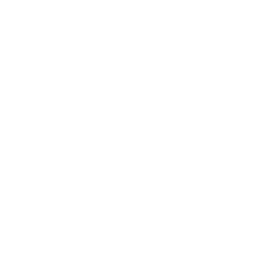
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Verkoopstest voor verpakking en schappositie in de detailhandel</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Detailhandel / marketing voor consumentenverpakte goederen &nbsp;|&nbsp; Maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Een merchandisingteam in de detailhandel testte vier verpakkingsontwerpen (CLASSIC_BOX, MODERN_POUCH, ECO_WRAP, PREMIUM_TIN) op drie schapposities (ooghoogte, heuphoogte, onderin) in een gecontroleerd winkelexperiment, waarbij de wekelijkse verkoop in eenheden werd gemeten. Een tweevoudige PROC ANOVA op 100 winkelweken kwantificeert hoeveel van de variatie in de verkoop elke factor verklaart en of de twee factoren op elkaar inwerken.

Beide hoofdeffecten zijn zeer significant: schappositie is de dominante drijfveer (F = 46.90, p < 0.0001), en ook het verpakkingsontwerp is van belang (F = 8.07, p = 0.0001). De interactie tussen ontwerp en positie is eveneens significant (F = 3.25, p = 0.0062), dus de beste verpakking hangt af van waar ze staat. Het model verklaart 61% van de variantie in wekelijkse eenheden (R-Square = 0.6098). Plaatsing op ooghoogte levert gemiddeld 51.1 eenheden per week op tegenover 30.0 op het onderste schap - een stijging van 70% die de waarde van premium schapruimte onderstreept. Deze resultaten wijzen het merchandisingteam op ooghoogte-facings voor de sterkste combinaties van ontwerp en positie.

## Gegevensbronnen

| Bron | Beschrijving | Records |
|--------|-------------|---------|
| WORK.SHELF_TEST | Wekelijkse verkoop in eenheden per winkel, verpakkingsontwerp en schappositie | 100 |

De onderstaande DATA-stap synthetiseert het winkel-weekpanel met een bekende gemiddelde structuur (4 ontwerpen x 3 posities) plus winkelverkeer en normale ruis, zodat de ANOVA effecten terugvindt die we kunnen toetsen aan het ontwerp. Deze omgeving draait zonder licentie, wat een gegenereerde tabel beperkt tot 100 waarnemingen; de analyse is afgestemd op die steekproef van 100 winkelweken.

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic shelf test sales data
   4 package designs x 3 shelf positions across 100 stores
   -------------------------------------------------------- */
GEGEVENS work.shelf_test;
    CALL streaminit(42);
    LENGTE package_design $14 shelf_position $10 store_id $8
           region $12 store_format $10;
    REEKS pkg_labels[4] $14 _temporary_ ('CLASSIC_BOX' 'MODERN_POUCH' 'ECO_WRAP' 'PREMIUM_TIN');
    REEKS shelf_labels[3] $10 _temporary_ ('EYE_LEVEL' 'WAIST_LEVEL' 'BOTTOM');
    REEKS region_labels[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    REEKS format_labels[3] $10 _temporary_ ('SUPERSTORE' 'STANDARD' 'EXPRESS');
    /* sales means: rows=package, cols=shelf_position */
    REEKS sales_mean[4, 3] _temporary_ (
        48  42  28
        55  51  35
        41  38  25
        62  53  31
    );
    obs = 0;
    DOE store_num = 1 TOT 100;
        store_id = cat('STR-', SCHRIJVEN(store_num, z4.));
        region_idx = int(rand('uniform') * 4) + 1;
        region = region_labels[region_idx];
        fmt_idx = int(rand('uniform') * 3) + 1;
        store_format = format_labels[fmt_idx];
        store_traffic = round(rand('normal', 5000, 1200), 1);
        ALS store_traffic < 1000 DAN store_traffic = 1000;
        DOE week = 1 TOT round(50 / (100 / 100));
            pkg_idx = int(rand('uniform') * 4) + 1;
            shelf_idx = int(rand('uniform') * 3) + 1;
            package_design = pkg_labels[pkg_idx];
            shelf_position = shelf_labels[shelf_idx];
            /* weekly units sold with store and random variation */
            weekly_units = round(
                rand('normal',
                    sales_mean[pkg_idx, shelf_idx]
                    + (store_traffic - 5000) * 0.003,
                    8.5),
                1);
            ALS weekly_units < 0 DAN weekly_units = 0;
            weekly_revenue = round(weekly_units * rand('normal', 4.29, 0.35), 0.01);
            ALS weekly_revenue < 0 DAN weekly_revenue = 0;
            obs + 1;
            UITVOER;
        EINDE;
    EINDE;
    VERWIJDEREN store_num region_idx fmt_idx pkg_idx shelf_idx obs;
UITVOEREN;

NOTE: DATA work.shelf_test

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.shelf_test (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.19 seconds
  cpu   0.19 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline sales by package design and shelf position
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.shelf_test n mean std;
    KLASSE package_design shelf_position;
    VARIABELE weekly_units weekly_revenue store_traffic;
UITVOEREN;

                                                  The MEANS Procedure

                                            Analysis Variable : WEEKLY_UNITS

        PACKAGE_DESIGN  SHELF_POSITION          N Obs           Mean        Std Dev
        ---------------------------------------------------------------------------
        CLASSIC_BOX     BOTTOM                      8     27.7500000     11.3986215
        CLASSIC_BOX     EYE_LEVEL                  15     47.0000000      9.2195445
        CLASSIC_BOX     WAIST_LEVEL                 4     44.5000000      5.0000000
        ECO_WRAP        BOTTOM                      9     25.3333333     12.3085336
        ECO_WRAP        EYE_LEVEL                   7     41.7142857      9.6387116
        ECO_WRAP        WAIST_LEVEL                 8     38.5000000      8.0178373
        MODERN_POUCH    BOTTOM                      9     40.4444444      8.8897569
        MODERN_POUCH    EYE_LEVEL                   6     55.3333333     10.3666131
        MOD

---

NOTE: PROC SGPLOT data=work.shelf_test

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


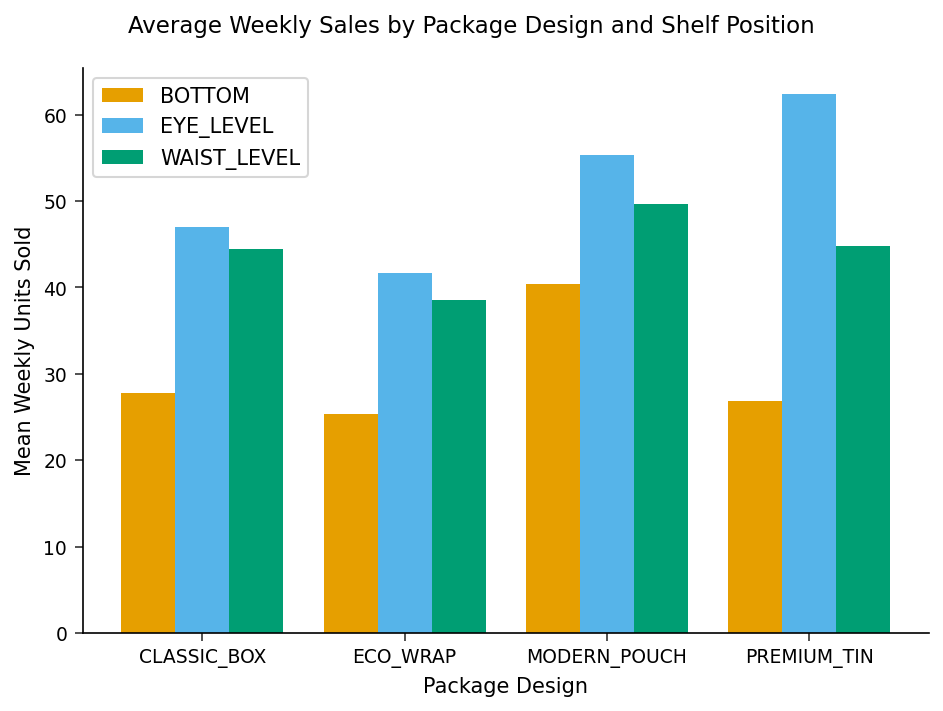

In [3]:
/* --------------------------------------------------------
   Clustered bar chart of mean weekly units
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.shelf_test;
    VBAR package_design / RESPONSE=weekly_units STAT=mean
        GROUP=shelf_position GROUPDISPLAY=CLUSTER;
    XAXIS label='Package Design';
    YAXIS label='Mean Weekly Units Sold';
    TITEL 'Average Weekly Sales by Package Design and Shelf Position';
UITVOEREN;

---

In [4]:
/* --------------------------------------------------------
   Two-way ANOVA: package_design x shelf_position
   on weekly unit sales with interaction.
   Scheffe multiple comparisons on each main effect; the
   interaction cell means are reported by PROC MEANS below.
   -------------------------------------------------------- */
PROCEDURE ANOVA GEGEVENS=work.shelf_test;
    KLASSE package_design shelf_position;
    MODEL weekly_units = package_design shelf_position
                         package_design*shelf_position;
    GEMIDDELDEN package_design shelf_position / SCHEFFE;
    TITEL 'Two-Way ANOVA: Package Design x Shelf Position on Sales';
UITVOEREN;


Dependent Variable: weekly_units

Source                  DF  Sum of Squares     Mean Square    F Value     Pr > F
--------------------------------------------------------------------------------
package_design           3       2214.2731        738.0910       8.07     0.0001
shelf_position           2       8576.5218       4288.2609      46.90     0.0000
package_design*shelf     6       1785.0246        297.5041       3.25     0.0062
Error                   88       8045.9705         91.4315          .          .
Corrected Total         99      20621.7900                          .          .

R-Square: 0.6098  Root MSE: 9.5620  Mean: 41.6100


Scheffe's Test for weekly_units

Alpha                            0.05
Error Degrees of Freedom         88
Error Mean Square                91.431483

Level of          -----------package_design----------
package_design        N         Mean      Std Dev

CLASSIC_BOX          27      40.9259      12.6610
ECO_WRAP             24      34.5000   

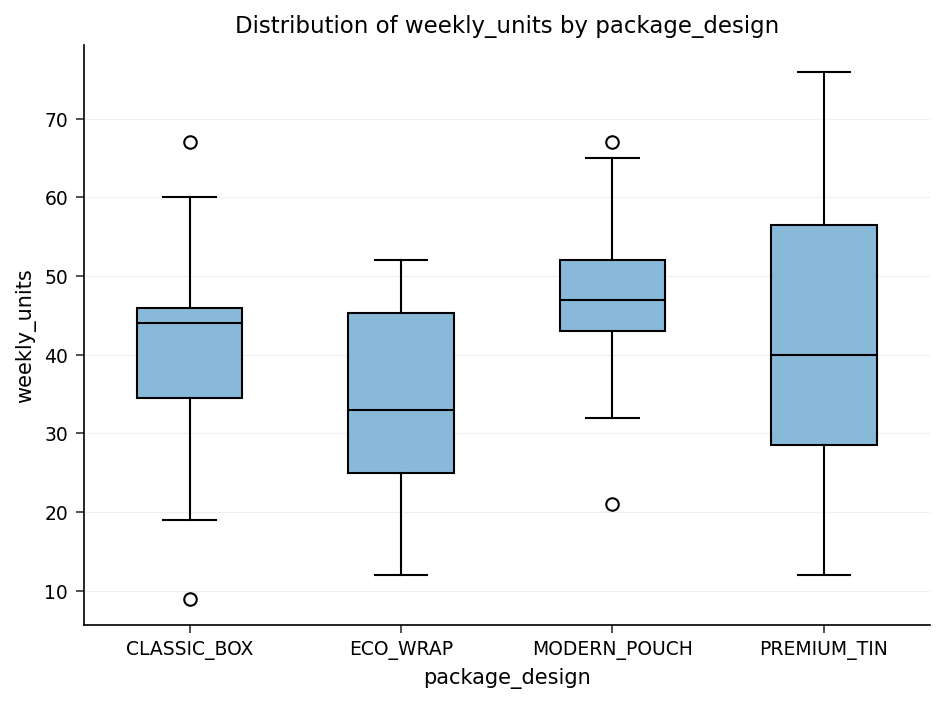

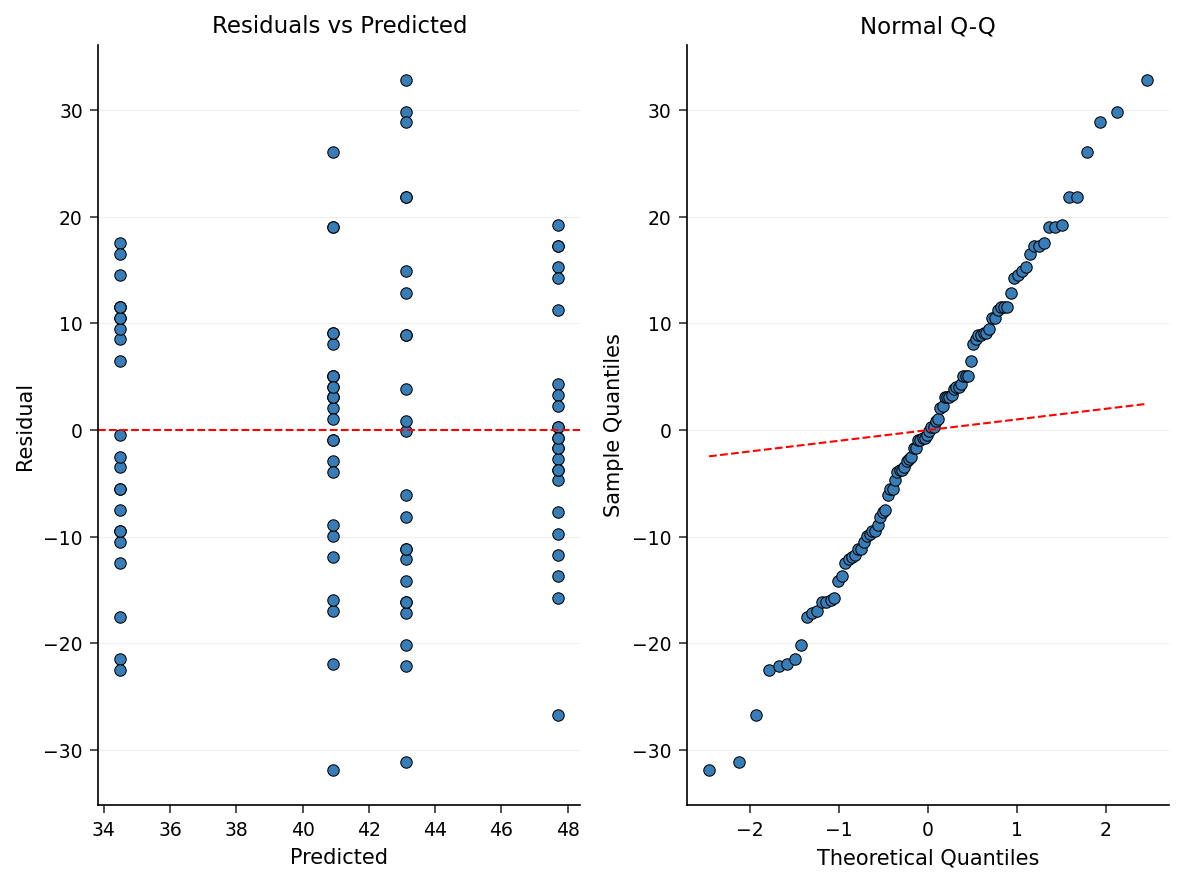

In [5]:
/* --------------------------------------------------------
   Cell means for planogram optimization report
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.shelf_test n mean std;
    KLASSE package_design shelf_position;
    VARIABELE weekly_units weekly_revenue;
    UITVOER out=work.planogram_means
        mean=mean_units mean_revenue
        std=std_units std_revenue
        n=n_weeks;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=work.planogram_means;
    WAAR _type_ = 3;
    TITEL 'Cell Means: Weekly Sales by Package x Shelf Position';
UITVOEREN;

---

### Interpretatie

De tweevoudige ANOVA bevestigt twee significante hoofdeffecten en een significante interactie op de wekelijkse verkoop in eenheden (100 winkelweken, R-Square = 0.6098, Root MSE = 9.56).

**Schappositie is de sterkste hefboom.** Ze levert de grootste kwadratensom (8576.5, F = 46.90, p < 0.0001). De marginale gemiddelden zijn 51.1 eenheden op ooghoogte, 44.7 op heuphoogte en 30.0 op het onderste schap. De toets van Scheffe scheidt alle drie de posities op het 0.05-niveau (verschil ooghoogte vs onderin 21.1, heuphoogte vs onderin 14.7, ooghoogte vs heuphoogte 6.4 - allemaal gemarkeerd). Het gat van ongeveer 21 eenheden tussen ooghoogte en het onderste schap is het belangrijkste resultaat dat premium schapruimtevergoedingen voor ooghoogte-schapruimte rechtvaardigt.

**Verpakkingsontwerp is van belang, maar minder.** Het hoofdeffect ervan is significant (F = 8.07, p = 0.0001) met marginale gemiddelden van 47.7 (MODERN_POUCH), 43.1 (PREMIUM_TIN), 40.9 (CLASSIC_BOX) en 34.5 (ECO_WRAP). De toets van Scheffe markeert alleen het verschil bij ECO_WRAP als significant: ECO_WRAP blijft 13.2 eenheden achter op MODERN_POUCH en 8.6 eenheden op PREMIUM_TIN (beide p < 0.05). De overige ontwerpparen zijn bij deze steekproefomvang statistisch niet te onderscheiden.

**De interactie is reeel (F = 3.25, p = 0.0062),** dus het beste ontwerp hangt af van de schaphoogte. De tabel met celgemiddelden maakt dit concreet: PREMIUM_TIN is de allerbeste cel op ooghoogte (62.3 eenheden) maar zakt naar 26.8 onderin - een van de zwakste cellen - een verschil van 35 eenheden. MODERN_POUCH is veel stabieler en houdt 55.3 op ooghoogte, 49.7 op heuphoogte en 40.4 onderin aan, de hoogste onderste-schapcel van alle ontwerpen. ECO_WRAP is op elke positie het zwakste ontwerp.

**Implicaties voor merchandising.** Reserveer ooghoogte-facings voor PREMIUM_TIN wanneer u die plaatsing kunt garanderen, aangezien het voordeel ervan lager in het schap instort. Gebruik MODERN_POUCH waar de schappositie variabel is of niet gecontroleerd kan worden, omdat dit het minst verliest wanneer het van ooghoogte wordt verdrongen. Herbeoordeel ECO_WRAP, dat op alle posities ondermaats presteert, tenzij de margestructuur ervan de lagere omloopsnelheid compenseert. (De onderstaande diagnostische grafieken - residuen tegenover voorspelde waarden en een normale Q-Q-plot - tonen geen grove afwijkingen van de ANOVA-aannames.)

---

In [6]:
/* --------------------------------------------------------
   Export planogram optimization data
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.planogram_means
    OUTFILE='packaging_shelf_test_results.csv'
    DBMS=csv REPLACE;
UITVOEREN;

NOTE: PROC EXPORT data=work.planogram_means outfile=packaging_shelf_test_results.csv

NOTE: Exported 20 rows to packaging_shelf_test_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>